![](forest-fire.jpeg)

Image by <a href="https://pixabay.com/users/ylvers-337353/?utm_source=link-attribution&amp;utm_medium=referral&amp;utm_campaign=image&amp;utm_content=432870" data-bcup-haslogintext="no">Ylvers</a> from <a href="https://pixabay.com//?utm_source=link-attribution&amp;utm_medium=referral&amp;utm_campaign=image&amp;utm_content=432870" data-bcup-haslogintext="no">Pixabay</a>


Ένα ακόμη καλοκαίρι έχει φτάσει στο τέλος του. Η Ελλάδα καλείται άλλη μια φορά να αξιολογήσει τις ζημιές που προκάλεσαν οι πυρκαγιές στον φυσικό της πλούτο, τις οικονομικές ζημίες σε καλλιέργειες, και το σημαντικότερο η τραγική απώλεια ανθρώπων και ζώων.

Στην ιστοσελίδα του Πυροσβεστικού Σώματος Ελλάδος [https://www.fireservice.gr](https://www.fireservice.gr/el_GR/synola-dedomenon) μπορείτε να βρείτε αρχεία δασικών και αστικών συμβάντων στα οποία κλήθηκε να επέμβει το Π.Σ. από το 2000 - 2021 σε μορφή `.xls|.xlsx`. Παρακάτω ακολουθεί η παρουσίαση των δεδομένων και η προετοιμασία τους για γραφική απεικόνιση. 'Επειτα θα βρείτε γραφήματα που παρουσιάζουν ετήσιες τάσεις σχετικά με το πλήθος των συμβάντων, την διάρκεια τους, έκταση ζημιών καθώς και του αριθμού των δυνάμεων που επενέβησαν. Πατήστε [εδώ](#sec-plots) αν επιθυμείτε να δείτε μόνο τα τελικά γραφήματα με τα συμπεράσματα τους.

## Σύντομη παρουσίαση και προετοιμασία των δεδομένων

*Με την πάροδο των ετών περισσότερες πληροφορίες προστίθενται στα αρχεία.*

**2000-2008**

* Υπηρεσία (`fire_service`)
* Δασαρχείο (`forest_department`)
* Περιοχή-Τοποθεσία (`location`)
* Νομός (`district`):
* Ημερ/νία Έναρξης (`start_date`)
* Ώρα Έναρξης (`start_time`)
* Ημερ/νία Κατάσβεσης (`end_date`)
* Ώρα Κατάσβεσης (`end_time`)

*Παρακάτω κατηγοριοποιούνται οι εκτάσεις που κάηκαν σε στρέμματα.*

* Δάση (`forest`)
* Δασική Έκταση (`forest_area`): Έπιπλέον δασική έκταση που καταστράφηκε.
* Άλση (`grove`)
* Χορτ/κές Εκτάσεις (`grassland`)
* Καλάμια - Βάλτοι (`marsh`)
* Γεωργικές Εκτάσεις (`crop_fields`)
* Υπολλείματα Καλλιεργιών (`crop_residues`)
* Σκουπιδότοποι (`dumps`)

**2009-2010**

* Δήμος (`borough`)

**2011**

*Το 2011 προστέθηκαν πληροφορίες για το ανθρώπινο δυναμικό και τα οχήματα που συμμετείχαν στην πυρόσβεση*

* ΠΥΡΟΣ, ΣΩΜΑ (`firemen`)
* ΠΕΖΟΠΟΡΑ ΤΜΗΜΑΤΑ (`patrol`)
* ΕΘΕΛΟΝΤΕΣ (`volunteers`)
* ΣΤΡΑΤΟΣ (`military`)
* ΑΛΛΕΣ ΔΥΝΑΜΕΙΣ (`other_groups`)
* ΠΥΡΟΣ. ΟΧΗΜ. (`fire_trucks`): Πυροσβεστικά οχήματα.
* ΟΧΗΜ. ΟΤΑ (`local_authorities`): Οχήματα της τοπικής αυτοδιοίκησης.
* ΒΥΤΙΟΦΟΡΑ (`private_trucks`)
* ΜΗΧΑΝΗΜΑΤΑ (`other_trucks`)
* ΕΛΙΚΟΠΤΕΡΑ (`helicopters`)
* Α/Φ CL415 (`canadair_new`): Canadair CL-415, το νεότερο μοντέλο του σκάφους πυρόσβεσης.
* Α/Φ CL215 (`canadair_old`): Canadair CL-215, το παλαιότερο μοντέλο του σκάφους πυρόσβεσης.
* Α/Φ PZL (`pzl`): PZL-Mielec, μονοκινητήρια αγροτικά αεροσκάφη.
* Α/Φ GRU. (`gru`): Άλλου είδους αεροσκάφη

**2012-2019**

* Διεύθυνση (address)

**2020-2021**

* Α/Α ΕΓΓΡΑΦΗΣ - Α/Α ENGAGE
* X-ENGAGE / Y-ENGAGE (Γεωγρ. μήκος/πλάτος)

In [151]:
#| code-summary: Εισάγουμε τις βιβλιοθήκες numpy, pandas, matplotlib και seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import ticker
import seaborn as sns
sns.set_theme(style='whitegrid', context='talk', palette='colorblind')

In [152]:
#| code-summary: Το πρώτο φύλλο excel περιέχει πληροφορίες για τα έτη 2000 - 2012 ανα φύλλο
data = pd.ExcelFile('datasets/Dasikes_Pyrkagies_2000-2012.xls')

print(data.sheet_names)

['2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012']


In [153]:
#| code-summary: Μια ματιά στα δεδομένα
data.parse('2000', skiprows=1).head()

,Υπηρεσία,Δασαρχείο,Περιοχή - Τοποθεσία,Νομός,Ημερ/νία Έναρξης,Ώρα Έναρξης,Ημερ/νία Κατασβεσης,Ώρα Κατάσβεσης,Δάση,Δασική Έκταση,Άλση,Χορτ/κές Εκτάσεις,Καλάμια - Βάλτοι,Γεωργικές Εκτάσεις,Υπολλείματα Καλλιεργειών,Σκουπιδότοποι
0,Π.Κ. ΑΧΑΡΝΩΝ - Δ.Π.Υ.ΑΘΗΝΑΣ,ΠΕΝΤΕΛΗΣ,ΚΡΥΟΝΕΡΙ,ΑΤΤΙΚΗΣ,2000-06-08,13:30:00,2000-06-08 00:00:00,15:00:00,3.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Π.Κ. ΠΟΛΥΔΕΝΔΡΙΟΥ,ΚΑΠΑΝΔΡΙΤΙΟΥ,ΑΓΡ.ΠΕΡ.ΑΦΙΔΝΩΝ,ΑΤΤΙΚΗΣ,2000-06-05,11:44:00,2000-06-05 00:00:00,13:00:00,0.0,0.0,0.0,0.0,0.0,8.0,0.0,0.0
2,1ος Π.Σ. ΑΘΗΝΩΝ,ΠΕΝΤΕΛΗΣ,ΚΑΡΕΑΣ,ΑΤΤΙΚΗΣ,2000-06-14,10:25:00,2000-06-14 00:00:00,14:00:00,2.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1ος Π.Σ. ΑΘΗΝΩΝ,ΠΕΝΤΕΛΗΣ,ΝΕΚΡΟΤΑΦΕΙΟ ΚΑΙΣΑΡΙΑΝΗΣ,ΑΤΤΙΚΗΣ,2000-07-23,11:10:00,2000-07-23 00:00:00,13:16:00,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2ος Π.Σ. ΑΘΗΝΩΝ,ΠΑΡΝΗΘΟΣ,ΔΡΟΣΟΠΟΥΛΟΥ ΑΝΩ ΛΙΟΣΙΑ,ΑΤΤΙΚΗΣ,2000-10-04,14:40:00,2000-10-04 00:00:00,17:20:00,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [154]:
#| code-summary: Το όνομα κάθε στήλης που θα χρησιμοποιηθεί για συντομία
column_names = ['fire_service', 'forest_department', 'location', 'district',
                'start_date', 'start_time', 'end_date', 'end_time',
                'forest', 'forest_area', 'grove', 'grassland', 'marsh', 'crop_fields', 'crop_residues', 'dumps']

In [155]:
#| code-summary: Tα φύλλα από το 2000 έως το 2008 περιέχουν τις παραπάνω στήλες
sheets = data.sheet_names[:9]
print(sheets)

['2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008']


In [156]:
#| code-summary: Φορτώνουμε αυτά τα πρώτα 9 φύλλα
df_dict = {}
for sheet in sheets:
    df = data.parse(sheet, skiprows=1, names=column_names)
    df_dict[sheet] = df

In [157]:
#| code-summary: Έλεγχος του πρώτου φύλλου
df = df_dict['2000']

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12980 entries, 0 to 12979
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   fire_service       12980 non-null  object        
 1   forest_department  10037 non-null  object        
 2   location           12979 non-null  object        
 3   district           12980 non-null  object        
 4   start_date         12980 non-null  datetime64[ns]
 5   start_time         12980 non-null  object        
 6   end_date           12949 non-null  object        
 7   end_time           12948 non-null  object        
 8   forest             12980 non-null  float64       
 9   forest_area        12980 non-null  float64       
 10  grove              12980 non-null  float64       
 11  grassland          12980 non-null  float64       
 12  marsh              12980 non-null  float64       
 13  crop_fields        12980 non-null  float64       
 14  crop_r

Με εξαίρεση κάποιες τιμές που λείπουν στις στήλες `forest_department` και `location` τα υπόλοιπα δεδομένα εμφανίζονται να είναι εντάξει. Τώρα θα επικεντρωθούμε στις στήλες ημερομηνιών και ωρών (`start_date`, `start_time`, `end_date`, `end_time`).

In [158]:
#| code-summary: Λανθασμένες ημερομηνίες
#| column: margin

for year, df in df_dict.items():
    if not df[df.end_date.apply(lambda x: isinstance(x, str))].end_date.empty:
        print("Year: ", year)
        print(df[df.end_date.apply(lambda x: isinstance(x, str))].end_date.sample(2))
        print()

Year:  2000
7599      10/7/0200
11906    10/11/1020
Name: end_date, dtype: object

Year:  2001
9154     5/9/0010
1351    21/9/0001
Name: end_date, dtype: object

Year:  2002
7038     3/3/0012
1730    13/2/0023
Name: end_date, dtype: object

Year:  2004
7369    13/9/0043
9407     4/9/0041
Name: end_date, dtype: object

Year:  2006
3929    21/8/0206
6937    27/6/0200
Name: end_date, dtype: object

Year:  2007
3242    13/1/0200
2108    24/8/0207
Name: end_date, dtype: object

Year:  2008
3462    11/8/0200
3957     4/9/0208
Name: end_date, dtype: object



Φαίνεται ότι υπάρχουν αρκετές ημερομηνίες που έχουν πληκτρολογηθεί λανθασμένα. Θα προσπαθήσουμε με μία εφαρμογή να διορθώσουμε τις λανθασμένες τιμές.

Η εφαρμογή πρώτα ελέγχει ποιες τιμές δεν έχουν μετατραπεί σε datetime objects (strings), και επιστρέφει Timestamp με την σωστή χρονολογία χρησιμοποιώντας τον ίδιο μήνα και ημέρα. Από την διόρθωση θα εξαιρεθούν ημερομηνίες που αφορούν τον Γενάρη του επόμενου έτους μιας και ορισμένες πυρκαγιές ξεκίνησαν Δεκέμβριο και τελείωσαν τον Ιανουάριο του επόμενου έτους. 

In [159]:
#| code-summary: Εφαρμογή διόρθωσης του έτους

from datetime import datetime

def fix_year(x, year):
    """A function to replace mistyped year
    on the end_date column
    
    Args:
        x (str or datetime): value of each row
        year (int): the correct year to replace
        
    Returns:
        pandas.Timestamp or original value x
    """
    
    # records that could not parsed as datetime objects
    if isinstance(x, str): 
        day, month, _ = x.split('/')
        return pd.Timestamp(year=year, month=int(month), day=int(day))
        
    # check that already parsed dates have the correct year
    elif isinstance(x, datetime):
        if x.year == year or pd.isnull(x): # exclude records with the correct year or null value
            return x
        elif x.year == (year + 1) and x.month == 1: # exclude records on January of the next year
            return x 
        else:
            return pd.Timestamp(year=year, month=int(x.month), day=int(x.day))

In [160]:
#| code-summary: Χρησιμοποιούμε την εφαρμογή
for year, df in df_dict.items():
    df["end_date"] = df.end_date.apply(fix_year, args=[int(year)])

In [161]:
#| code-summary: Ενώνουμε ημερομηνία και ώρα
for df in df_dict.values():
    df['start'] = pd.to_datetime(df.start_date.dt.strftime("%Y-%m-%d") + ' ' + df.start_time.map(str))
    df['end'] = pd.to_datetime(df.end_date.dt.strftime("%Y-%m-%d") + ' ' + df.end_time.map(str), errors='coerce')

In [162]:
#| code-summary: Στήλες των ετών 2009-2010

print(data.parse('2009', skiprows=1).columns)
print(data.parse('2010', skiprows=1).columns)

Index(['Υπηρεσία', 'Δασαρχείο', 'Περιοχή - Τοποθεσία', 'Δήμος', 'Νομός',
       'Ημερ/νία Έναρξης', 'Ώρα Έναρξης', 'Ημερ/νία Κατασβεσης',
       'Ώρα Κατάσβεσης', 'Δάση', 'Δασική Έκταση', 'Άλση', 'Χορτ/κές Εκτάσεις',
       'Καλάμια - Βάλτοι', 'Γεωργικές Εκτάσεις', 'Υπολλείματα Καλλιεργειών',
       'Σκουπιδότοποι'],
      dtype='object')
Index(['Υπηρεσία', 'Δασαρχείο', 'Περιοχή - Τοποθεσία', 'Δήμος', 'Νομός',
       'Ημερ/νία Έναρξης', 'Ώρα Έναρξης', 'Ημερ/νία Κατασβεσης',
       'Ώρα Κατάσβεσης', 'Δάση', 'Δασική Έκταση', 'Άλση', 'Χορτ/κές Εκτάσεις',
       'Καλάμια - Βάλτοι', 'Γεωργικές Εκτάσεις', 'Υπολλείματα Καλλιεργειών',
       'Σκουπιδότοποι'],
      dtype='object')


In [163]:
#| code-summary: Προσθήκη της στήλης δήμου `borough`
column_names = ['fire_service', 'forest_department', 'location', 'borough', 'district',
                'start_date', 'start_time', 'end_date', 'end_time',
                'forest', 'forest_area', 'grove', 'grassland', 'marsh', 'crop_fields', 'crop_residues', 'dumps']

In [164]:
#| code-summary: Προσθήκη των δύο ετών στις υπόλοιπες

sheets = ['2009', '2010']
for sheet in sheets:
    df = data.parse(sheet, skiprows=1, names=column_names)
    df_dict[sheet] = df

In [165]:
#| code-summary: Λανθασμένες ημερ/νίες
#| column: margin

for year, df in df_dict.items():
    if not df[df.end_date.apply(lambda x: isinstance(x, str))].end_date.empty:
        print("Year: ", year)
        print(df[df.end_date.apply(lambda x: isinstance(x, str))].end_date.sample(2))
        print()

Year:  2009
2629    20/5/0209
2273    21/5/0209
Name: end_date, dtype: object



In [166]:
#| code-summary: Διόρθωση ημερ/νιών
for year, df in df_dict.items():
    if year in sheets:
        df["end_date"] = df.end_date.apply(fix_year, args=[int(year)])

In [167]:
#| code-summary: Ενώνουμε ημερομηνία και ώρα
for year, df in df_dict.items():
    if year in sheets:
        df['start'] = pd.to_datetime(df.start_date.dt.strftime("%Y-%m-%d") + ' ' + df.start_time.map(str))
        df['end'] = pd.to_datetime(df.end_date.dt.strftime("%Y-%m-%d") + ' ' + df.end_time.map(str), errors='coerce')

In [168]:
#| code-summary: Το 2011 προστίθενται ανθρώπινο δυναμικό και οχήματα
data.parse('2011', skiprows=1).columns

Index(['Υπηρεσία', 'Νομός', 'Ημερ/νία Έναρξης', 'Ώρα Έναρξης',
       'Ημερ/νία Κατασβεσης', 'Ώρα Κατάσβεσης', 'Δασαρχείο', 'Δήμος',
       'Περιοχή - Τοποθεσία', 'Δάση', 'Δασική Έκταση', 'Άλση',
       'Χορτ/κές Εκτάσεις', 'Καλάμια - Βάλτοι', 'Γεωργικές Εκτάσεις',
       'Υπολλείματα Καλλιεργειών', 'Σκουπιδότοποι', 'ΠΥΡΟΣ. ΣΩΜΑ',
       'ΠΕΖΟΠΟΡΑ ΤΜΗΜΑΤΑ', 'ΕΘΕΛΟ-ΝΤΕΣ', 'ΣΤΡΑΤΟΣ', 'ΑΛΛΕΣ ΔΥΝΑΜΕΙΣ',
       'ΠΥΡΟΣ. ΟΧΗΜ.', 'ΟΧΗΜ. ΟΤΑ', 'ΒΥΤΙΟ- ΦΟΡΑ', 'ΜΗΧΑΝΗΜΑΤΑ',
       'ΕΛΙΚΟ- ΠΤΕΡΑ', 'Α/Φ CL415', 'Α/Φ CL215', 'Α/Φ PZL', 'Α/Φ GRU.'],
      dtype='object')

In [169]:
#| code-summary: Στήλες που θα χρησιμοποιηθούν
column_names = ['fire_service', 'district', 'start_date', 'start_time', 'end_date', 'end_time',
                'forest_department', 'borough', 'location',
                'forest', 'forest_area', 'grove', 'grassland', 'marsh', 'crop_fields', 'crop_residues', 'dumps',
                'firemen', 'patrol', 'volunteers', 'military', 'other_groups', 'fire_trucks', 'local_authorities',
                'private_trucks', 'other_trucks', 'helicopters', 'canadair_new', 'canadair_old', 'pzl',
                'gru']

In [170]:
#| code-summary: Προσθήκη του 2011

sheet = '2011'
df = data.parse(sheet, skiprows=1, names=column_names)
df_dict[sheet] = df
df["end_date"] = df.end_date.apply(fix_year, args=[int(sheet)])
df['start'] = pd.to_datetime(df.start_date.dt.strftime("%Y-%m-%d") + ' ' + df.start_time.map(str))
df['end'] = pd.to_datetime(df.end_date.dt.strftime("%Y-%m-%d") + ' ' + df.end_time.map(str), errors='coerce')

In [171]:
#| code-summary: Το 2012 προστίθεται η διεύθυνση `address`

data.parse('2012', skiprows=1).columns

Index(['Υπηρεσία', 'Νομός', 'Ημερ/νία Έναρξης', 'Ώρα Έναρξης',
       'Ημερ/νία Κατασβεσης', 'Ώρα Κατάσβεσης', 'Δασαρχείο', 'Δήμος',
       'Περιοχή', 'Διεύθυνση', 'Δάση', 'Δασική Έκταση', 'Άλση',
       'Χορτ/κές Εκτάσεις', 'Καλάμια - Βάλτοι', 'Γεωργικές Εκτάσεις',
       'Υπολλείματα Καλλιεργειών', 'Σκουπι-δότοποι', 'ΠΥΡΟΣ. ΣΩΜΑ',
       'ΠΕΖΟΠΟΡΑ ΤΜΗΜΑΤΑ', 'ΕΘΕΛΟ-ΝΤΕΣ', 'ΣΤΡΑΤΟΣ', 'ΑΛΛΕΣ ΔΥΝΑΜΕΙΣ',
       'ΠΥΡΟΣ. ΟΧΗΜ.', 'ΟΧΗΜ. ΟΤΑ', 'ΒΥΤΙΟ- ΦΟΡΑ', 'ΜΗΧΑΝΗ-ΜΑΤΑ',
       'ΕΛΙΚΟ- ΠΤΕΡΑ', 'Α/Φ CL415', 'Α/Φ CL215', 'Α/Φ PZL', 'Α/Φ GRU.'],
      dtype='object')

In [172]:
#| code-summary: Ανανέωση των ονομάτων των στηλών
column_names = ['fire_service', 'district', 'start_date', 'start_time', 'end_date', 'end_time',
                'forest_department', 'borough', 'location', 'address',
                'forest', 'forest_area', 'grove', 'grassland', 'marsh', 'crop_fields', 'crop_residues', 'dumps',
                'firemen', 'patrol', 'volunteers', 'military', 'other_groups', 'fire_trucks', 'local_authorities',
                'private_trucks', 'other_trucks', 'helicopters', 'canadair_new', 'canadair_old', 'pzl',
                'gru']

In [173]:
#| code-summary: Φόρτωση του 2012
sheet = '2012'
df = data.parse(sheet, skiprows=1, names=column_names)
df_dict[sheet] = df
df["end_date"] = df.end_date.apply(fix_year, args=[int(sheet)])
df['start'] = pd.to_datetime(df.start_date.dt.strftime("%Y-%m-%d") + ' ' + df.start_time.map(str))
df['end'] = pd.to_datetime(df.end_date.dt.strftime("%Y-%m-%d") + ' ' + df.end_time.map(str), errors='coerce')

In [174]:
#| code-summary: Φόρτωση των ετών 2013-2019

import glob

for sheet in range(2013, 2020):
    # εύρεση του αρχείου
    file = glob.glob('datasets/Dasikes_Pyrkagies_' + str(sheet) + '*')[0]
    
    # φόρτωση του αρχείου
    df = pd.read_excel(file, skiprows=1, names=column_names)
    df_dict[str(sheet)] = df
    
    # διόρθωση των ημερομηνιών
    df["end_date"] = df.end_date.apply(fix_year, args=[sheet])
    
    # ένωση των ημερ/νιών με τις ώρες
    df['start'] = pd.to_datetime(df.start_date.dt.strftime("%Y-%m-%d") + ' ' + df.start_time.map(str))
    df['end'] = pd.to_datetime(df.end_date.dt.strftime("%Y-%m-%d") + ' ' + df.end_time.map(str), errors='coerce')

In [175]:
#| code-summary: Στήλες του 2020 και 2021
pd.read_excel('datasets/Dasikes_Pyrkagies_2020.xls', skiprows=1).columns

Index(['Α/Α ΕΓΓΡΑΦΗΣ', 'Α/Α ENGAGE', 'X-ENGAGE', 'Y-ENGAGE', 'Υπηρεσία',
       'Νομός', 'Ημερ/νία Έναρξης', 'Ώρα Έναρξης', 'Ημερ/νία Κατασβεσης',
       'Ώρα Κατάσβεσης', 'Δασαρχείο', 'Δήμος', 'Περιοχή', 'Διεύθυνση', 'Δάση',
       'Δασική Έκταση', 'Άλση', 'Χορτ/κές Εκτάσεις', 'Καλάμια - Βάλτοι',
       'Γεωργικές Εκτάσεις', 'Υπολλείματα Καλλιεργειών', 'Σκουπι-δότοποι',
       'ΠΥΡΟΣ. ΣΩΜΑ', 'ΠΕΖΟΠΟΡΑ ΤΜΗΜΑΤΑ', 'ΕΘΕΛΟ-ΝΤΕΣ', 'ΣΤΡΑΤΟΣ',
       'ΑΛΛΕΣ ΔΥΝΑΜΕΙΣ', 'ΠΥΡΟΣ. ΟΧΗΜ.', 'ΟΧΗΜ. ΟΤΑ', 'ΒΥΤΙΟ- ΦΟΡΑ',
       'ΜΗΧΑΝΗ-ΜΑΤΑ', 'ΕΛΙΚΟ- ΠΤΕΡΑ', 'Α/Φ CL415', 'Α/Φ CL215', 'Α/Φ PZL',
       'Α/Φ GRU.'],
      dtype='object')

In [176]:
#| code-summary: Το 2020-2021 προστέθηκαν γεωγρ. συντεταγμένες και ευρετήριο που δεν θα συμπεριληφθεί στο τελικό αρχείο
column_names = ['longitude', 'latitude', 'fire_service', 'district', 'start_date', 'start_time', 'end_date', 'end_time',
                'forest_department', 'borough', 'location', 'address',
                'forest', 'forest_area', 'grove', 'grassland', 'marsh', 'crop_fields', 'crop_residues', 'dumps',
                'firemen', 'patrol', 'volunteers', 'military', 'other_groups', 'fire_trucks', 'local_authorities',
                'private_trucks', 'other_trucks', 'helicopters', 'canadair_new', 'canadair_old', 'pzl',
                'gru']

In [177]:
#| code-summary: Φόρτωση των ετών 2020-2021

for sheet in [2020, 2021]:
    # εύρεση του αρχείου
    file = glob.glob('datasets/Dasikes_Pyrkagies_' + str(sheet) + '*')[0]
    
    # φόρτωση του αρχείου
    df = pd.read_excel(file, skiprows=1,
                   usecols=list(range(2, 36, 1)), names=column_names)
    df_dict[str(sheet)] = df
    
    # διόρθωση των ημερομηνιών
    df["end_date"] = df.end_date.apply(fix_year, args=[sheet])
    
    # ένωση των ημερ/νιών με τις ώρες
    df['start'] = pd.to_datetime(df.start_date.dt.strftime("%Y-%m-%d") + ' ' + df.start_time.map(str))
    df['end'] = pd.to_datetime(df.end_date.dt.strftime("%Y-%m-%d") + ' ' + df.end_time.map(str), errors='coerce')

In [178]:
#| code-summary: Συνδιασμός όλων των αρχείων σε ένα πίνακα που ονομάζεται `wildfires`
wildfires = pd.concat(df_dict.values())

In [179]:
#| code-summary: Ορίζουμε ως μη διαθέσιμες όσες ημερ/νίες κατάσβεσης προηγούνται των αντίστοιχων ημερ/νιών έναρξης του συμβάντος
wildfires.loc[(wildfires.start > wildfires.end), 'end'] = pd.NaT

In [180]:
#| code-summary: Αυτό είναι το τελικό μας αρχείο προς παρουσίαση
print(wildfires.info())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 223260 entries, 0 to 9513
Data columns (total 36 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   fire_service       223260 non-null  object        
 1   forest_department  148424 non-null  object        
 2   location           154541 non-null  object        
 3   district           223252 non-null  object        
 4   start_date         223260 non-null  datetime64[ns]
 5   start_time         223260 non-null  object        
 6   end_date           203493 non-null  datetime64[ns]
 7   end_time           203603 non-null  object        
 8   forest             223259 non-null  float64       
 9   forest_area        223260 non-null  float64       
 10  grove              223260 non-null  float64       
 11  grassland          223260 non-null  float64       
 12  marsh              223260 non-null  float64       
 13  crop_fields        223258 non-null  float64   

In [181]:
#| code-summary: Τυχαίο δείγμα 5 καταγραφών
#| column: page
wildfires.sample(5)

,fire_service,forest_department,location,district,start_date,start_time,end_date,end_time,forest,forest_area,...,private_trucks,other_trucks,helicopters,canadair_new,canadair_old,pzl,gru,address,longitude,latitude
11546,Π.Υ. ΛΕΥΚΑΔΑΣ,ΑΜΦΙΛΟΧΙΑΣ,Δ.Δ. ΑΚΤΙΟΥ Δ. ΑΝΑΚΤΟΡΙΟΥ,ΛΕΥΚΑΔΟΣ,2007-08-15,14:19,2007-08-16,19:10,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9286,Π.Υ. ΚΑΣΤΕΛΛΙΟΥ (ΚΙΣΣΑΜΟΥ),ΧΑΝΙΩΝ,NaN,ΧΑΝΙΩΝ,2013-03-20,14:40,2013-03-20,17:30,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,ΓΛΩΣΣΑ ΚΙΣΑΜΟΥ (Δ.Ε. ΚΟΛΥΜΒΑΡΙΟΥ),NaN,NaN
2908,Π.Κ. ΝΕΑΣ ΖΙΧΝΗΣ,ΣΕΡΡΩΝ,ΘΟΛΟΣ,ΣΕΡΡΩΝ,2016-10-05,12:30,NaT,NaN,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,ΑΓΡ. ΠΕΡ. ΘΟΛΟΥ,NaN,NaN
2012,Π.Υ. ΓΙΑΝΝΙΤΣΩΝ,NaN,ΔΡΟΣΕΡΟ,ΠΕΛΛΑΣ,2021-09-18,17:55,2021-09-18,18:40,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,ΑΓΡΟΤΙΚΗ ΠΕΡΙΟΧΗ ΔΡΟΣΕΡΟΥ,22.273724,40.827393
3345,Π.Κ. ΑΣΤΡΟΧΩΡΙΟΥ,3,ΔΗΜΟΣ ΤΕΤΡΑΦΥΛΙΑΣ,ΑΡΤΑΣ,2004-09-12,19:33:00,2004-09-12,21:10:00,0.0,0.1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Κλιματολογικά δεδομένα

Θα χρησιμοποιηθούν δεδομένα των καιρικών συνθηκών της Ελλάδας του εκάστοτε έτους για σύγκριση με τα στοιχεία των πυρκαγιών. Τα δεδομένα προέρχονται από την ιστοσελίδα <https://climateknowledgeportal.worldbank.org/> και αφορούν δείκτες παρατεταμένης ξηρασίας και υψηλών θερμοκρασιών ανά έτος (`Warm spell duration index`, `max number of consecutive dry days`).

In [182]:
#| layout: [[1, 1]]

col_names = ['year', 'warm_days']

warm_spell = pd.read_csv('datasets/wsdi_timeseries_annual_era_1970-2020_GRC.csv', usecols=[0, 1], names=col_names, skiprows=2)

warm_spell.info()
warm_spell.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   year       51 non-null     int64  
 1   warm_days  51 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 944.0 bytes


,year,warm_days
0,1970,11.94
1,1971,1.05
2,1972,0.48
3,1973,3.06
4,1974,1.22


In [183]:
#| layout: [[1, 1]]

col_names = ['year', 'dry_days']

max_dry_days = pd.read_csv('datasets/cdd_timeseries_annual_era_1970-2020_GRC.csv', usecols=[0, 1], names=col_names, skiprows=2)

print(max_dry_days.info())
max_dry_days.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   year      51 non-null     int64  
 1   dry_days  51 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 944.0 bytes
None


,year,dry_days
0,1970,34.75
1,1971,23.84
2,1972,25.08
3,1973,26.60
4,1974,37.09


In [184]:
#| code-summary: Επιλέγουμε δεδομένα μόνο από το 2000 και μετά

warm_spell_subset = warm_spell[warm_spell.year >= 2000]
max_dry_days_subset = max_dry_days[max_dry_days.year >= 2000]

## Γραφική απεικόνιση των δεδομένων {#sec-plots}

Παρακάτω με την χρήση τον βιβλιοθηκών pandas, matplotlib και seaborn θα παρουσιάσουμε τα δεδομένα με κάποια βασικά γραφήματα.

In [ ]:
incidents_per_year = wildfires.start.dt.year.value_counts(sort=False).rename_axis('year').reset_index(name='incidents').merge(warm_spell_subset, on='year').merge(max_dry_days_subset, on='year')


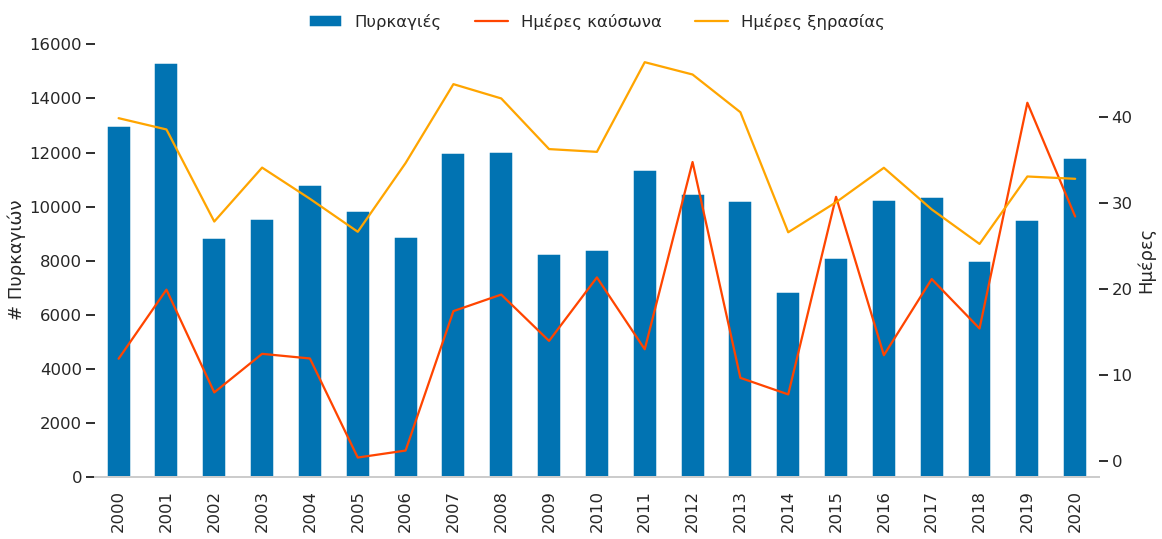

In [186]:
#| code-summary: Ραβδόγραμμα
#| column: page
#| fig-align: left
#| fig-cap: Πλήθος πυρκαγιών ανά έτος

fig, ax = plt.subplots(figsize=(18,8))
incidents_per_year.plot(kind='bar', ax=ax, x='year', y='incidents')
incidents_per_year['warm_days'].plot(kind='line', secondary_y=True, ax=ax, color='orangered')
incidents_per_year['dry_days'].plot(kind='line', secondary_y=True, ax=ax, color='orange')

handles = ax.get_legend_handles_labels()[0] + ax.right_ax.get_legend_handles_labels()[0]
labels = ['Πυρκαγιές', 'Ημέρες καύσωνα', 'Ημέρες ξηρασίας']
ax.legend(handles, labels, loc='upper center', frameon=False, ncol=3, bbox_to_anchor=(0.5, 1.1))

ax.grid(False)
ax.right_ax.grid(False)
ax.tick_params(axis='x', labelrotation = 90)
sns.despine(fig, top=True, left=True)
ax.set_xlabel('')
ax.set_ylabel('# Πυρκαγιών')
ax.right_ax.set_ylabel('Ημέρες');

Τα περισσότερα περιστατικά πυρκαγιών καταγράφηκαν το 2000 με 2001 με 12980 και 15303 αντίστοιχα. Καλύτερη χρονιά ήταν το 2014 με 6833 πυρκαγιές. Το πλήθος των πυρκαγιών έχει ξεκάθαρη σχέση με τις ημέρες ξηρασίας που επικρατούν το εκάστοτε έτος ενώ οι ημέρες καύσωνα φαίνεται να έχουν θετική συσχέτιση αλλά μικρότερη.

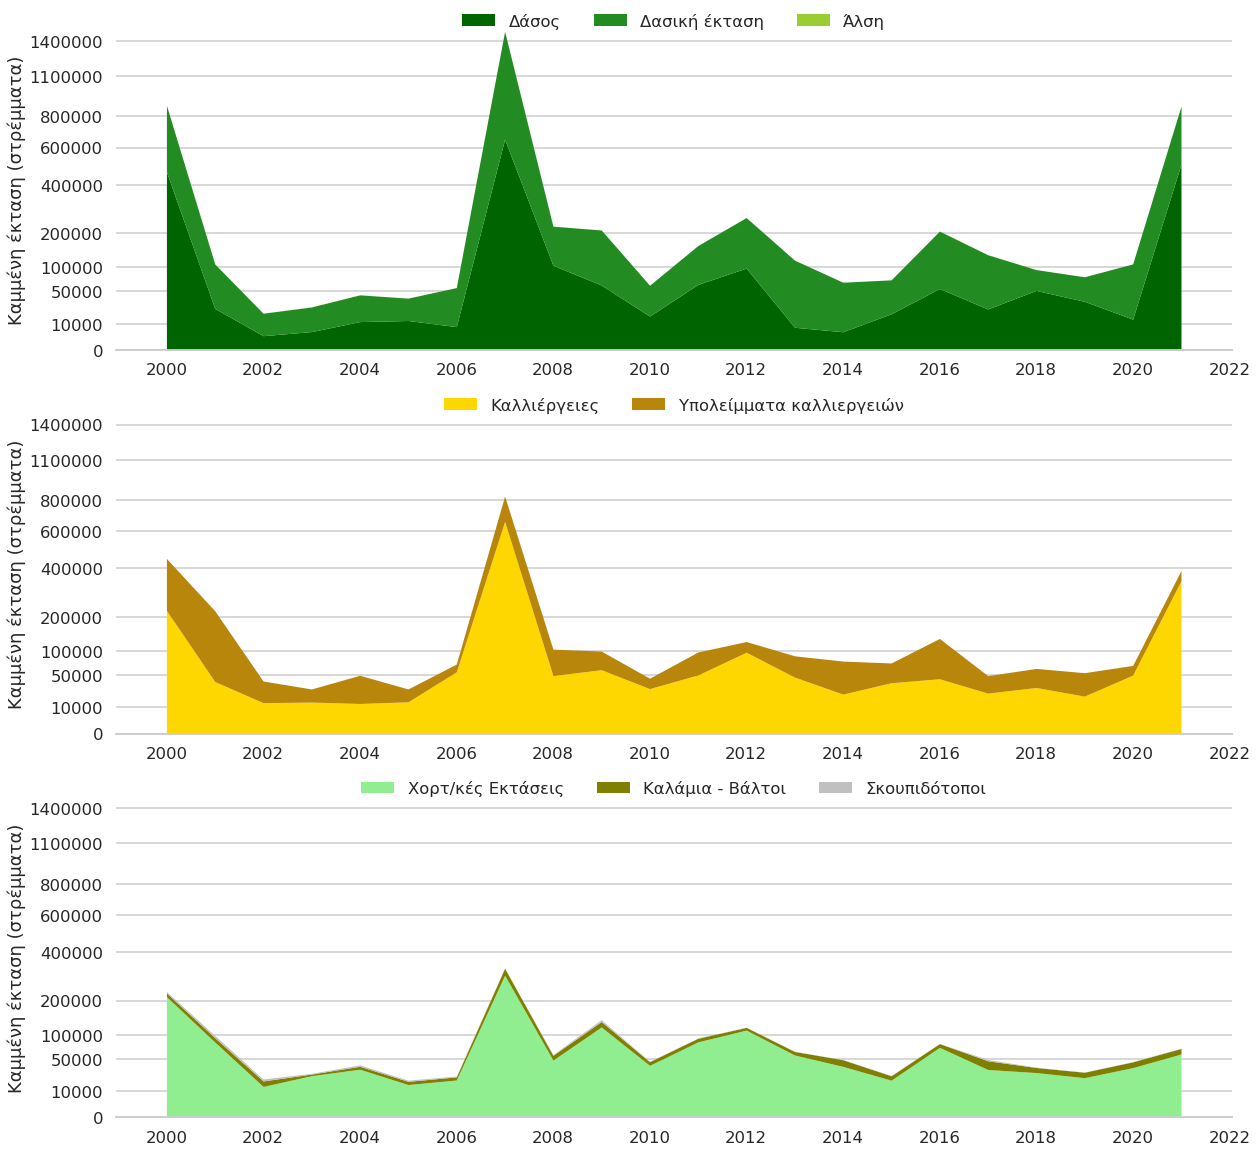

In [187]:
#| code-summary: Διάγραμμα περιοχής
#| fig-cap: "Καμμένες εκτάσεις ανά έτος (2000 - 2021)"
#| column: page
#| fig-align: left

fig, axes = plt.subplots(3, 1, figsize=(20, 20))
wildfires.groupby(wildfires.start.dt.year).sum().plot.area(ax=axes[0],
                                                           y=['forest', 'forest_area', 'grove'],
                                                           color=['darkgreen', 'forestgreen', 'yellowgreen'],
                                                           linewidth=0)

wildfires.groupby(wildfires.start.dt.year).sum().plot.area(ax=axes[1],
                                                           y=['crop_fields', 'crop_residues'],
                                                           color=['gold', 'darkgoldenrod'],
                                                           linewidth=0)

wildfires.groupby(wildfires.start.dt.year).sum().plot.area(ax=axes[2],
                                                           y=['grassland', 'marsh', 'dumps'],
                                                           color=['lightgreen', 'olive', 'silver'],
                                                           linewidth=0)

# make a square root scale for y, otherwise should recalculate area field
def forward(x):
    return x**(1/2)


def inverse(x):
    return x**2

mylabels = [['Δάσος', 'Δασική έκταση', 'Άλση'], ['Καλλιέργειες', 'Υπολείμματα καλλιεργειών'], ['Χορτ/κές Εκτάσεις', 'Καλάμια - Βάλτοι', 'Σκουπιδότοποι']]

for i, ax in enumerate(axes):
    ax.xaxis.grid(False)
    sns.despine(ax=ax, right=True, left=True, top=True)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(2))
    ax.set_ylim([0, 1_500_000])
    ax.set_yscale('function', functions=(forward, inverse)) # set the square root scale
    ax.yaxis.set_major_locator(ticker.FixedLocator([0, 10_000, 50_000, 100_000, 200_000, 400_000,
                                                    600_000, 800_000, 1_100_000, 1_400_000]))
    ax.yaxis.get_major_formatter().set_scientific(False)
    ax.set_xlabel('')
    ax.set_ylabel('Καμμένη έκταση (στρέμματα)')
    handles, _ = ax.get_legend_handles_labels()
    ax.legend(handles, mylabels[i], loc='upper center', frameon=False, ncol=3, bbox_to_anchor=(0.5, 1.1))

Το 2000 είχαμε την πυρκαγιά της Σάμου, τη μεγαλύτερη στην ιστορία του νησιού με 145.000 στρέμματα καμμένα όπως επίσης και του Ξυλόκαστρου Κορινθίας όπου κάηκαν συνολικά 200.000 στρέμματα.^[[<<Οι 10 πιο καταστροφικές πυρκαγιές της Ελλάδας>> https://dasarxeio.com 17/08/2017](https://dasarxeio.com/2017/08/17/47883/)]

Το 2007, η χειρότερη χρονιά για την Πελοπόννησο, με την μεγαλύτερη καταστροφή φυσικού πλούτου μέχρι σήμερα. Σε δύο μήνες, Ιούλιο και Αύγουστο ξέσπασαν πυρκαγιές στο Αίγιο, την Καλαμάτα, την Καλλιθέα Λακωνίας, την Ζαχάρω και το Αγραπιδώρι Ηλείας όπου έκαψαν άνω του ενός εκατομμυρίου στρεμμάτων.^[[<<Οι 10 πιο καταστροφικές πυρκαγιές της Ελλάδας>> https://dasarxeio.com 17/08/2017](https://dasarxeio.com/2017/08/17/47883/)]

Το 2021 ήταν σειρά της Εύβοιας να υποστεί μία από τις μεγαλύτερες καταστροφές του φυσικού της πλούτου με 511.854 καμμένα στρέμματα. Ακολούθησε η πυρκαγιά στην Αρχαία Ολυμπία με 150.000 καμμένα στρέμματα και την Ανατολική Μάνη με 101.001 καμμένα στρέμματα.^[[<<Ημερίδα για τον απολογισμό της αντιπυρικής περιόδου έτους 2021>> Πυροσβεστικό Σώμα. 14/12/2021](https://www.fireservice.gr/el_GR/-/emerida-gia-ton-apologismo-tes-antipyrikes-periodou-etous-2021)]

In [188]:
#| code-summary: Υπολογισμός διάρκειας πυρκαγιών σε όσα δεδομένα έχουμε διαθέσιμη την ημερ/νία πυρόσβεσης

# αφαιρούμε τις τιμές που λείπουν
wildfires_subset = wildfires[['start', 'end']].dropna()

print("Πλήθος εγγραφών που περιλαμβάνουν διάρκεια: ", wildfires_subset.shape[0])

wildfires_subset['duration'] = (wildfires_subset.end - wildfires_subset.start).dt.total_seconds() / 360 / 24

Πλήθος εγγραφών που περιλαμβάνουν διάρκεια:  201425


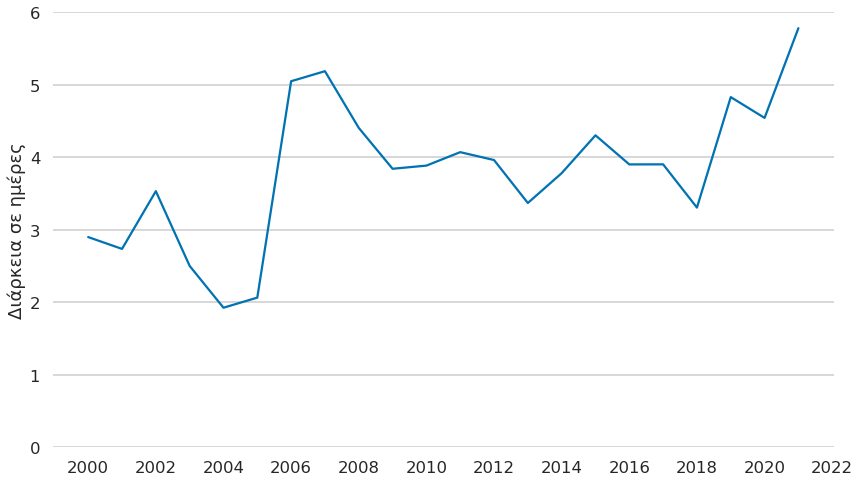

In [201]:
#| code-summary: Γραμμικό διάγραμμα
#| fig-cap: "Ετήσιος μέσος όρος διάρκειας πυρκαγιών (2000 - 2021)"
#| column: page
#| fig-align: left

fig, ax = plt.subplots(figsize=(14, 8))
wildfires_subset.groupby(wildfires_subset.start.dt.year).mean().plot(y='duration', ax=ax, legend=False)

sns.despine(ax=ax, top=True, left=True, right=True, bottom=True)
ax.xaxis.grid(False)
ax.xaxis.set_major_locator(ticker.MultipleLocator(2))
ax.set_ylim([0, 6])
ax.set(xlabel='', ylabel='Διάρκεια σε ημέρες');

Με την πάροδο των ετών η διάρκεια των πυρκαγιών αυξάνεται με αποκορύφωμα το 2021. Επίσης με μία σύγκριση με το προηγούμενο γράφημα φαίνεται σαφής συσχέτιση της διάρκειας με την έκταση των καταστροφών.

In [204]:
#| code-summary: Επιλογή των ετών 2011-2021 για την παρουσίαση του ανθρώπινου δυναμικού και των οχημάτων πυρόσβεσης

wildfires_subset = wildfires[wildfires.start.dt.year >= 2011]

,forest,forest_area,grove,grassland,marsh,crop_fields,crop_residues,dumps,firemen,patrol,...,local_authorities,private_trucks,other_trucks,helicopters,canadair_new,canadair_old,pzl,gru,longitude,latitude
start,,,,,,,,,,,,,,,,,,,,,
2011,5.544340,8.540822,0.002530,7.364124,0.718163,4.449048,4.163014,0.043343,5.461002,0.628914,...,0.125463,0.118882,0.060400,0.019224,0.025481,0.016401,0.046112,0.000353,NaN,NaN
2012,9.369998,15.145638,0.005374,10.651002,0.672556,9.268614,2.592545,0.061130,5.802774,0.614856,...,0.163803,0.110252,0.053742,0.015750,0.032073,0.024150,0.041523,0.000382,NaN,NaN
2013,0.735661,10.846175,0.004413,5.587623,0.654345,4.591438,4.113613,0.037848,5.265214,0.501079,...,0.116811,0.082483,0.047764,0.012260,0.021381,0.019027,0.030012,0.000196,NaN,NaN
2014,0.707985,9.117623,0.005004,5.567032,1.547594,3.344768,7.945305,0.037385,5.401025,0.600029,...,0.131128,0.077711,0.041270,0.014049,0.015367,0.017562,0.035855,0.000293,NaN,NaN
2015,2.355761,6.504809,0.005232,2.491328,0.626428,4.675048,4.339309,0.048937,5.216930,0.412026,...,0.102981,0.073787,0.038064,0.010347,0.011702,0.012688,0.025868,0.000616,NaN,NaN
2016,5.383560,14.789517,0.025075,6.993830,0.776112,4.293802,8.646254,0.032561,5.453863,0.485032,...,0.094746,0.070962,0.037625,0.016863,0.015206,0.016376,0.028658,0.000000,NaN,NaN
2017,2.370260,10.449016,0.027094,3.239060,1.286950,2.317981,2.434971,0.211719,5.427933,0.423133,...,0.099136,0.064666,0.032722,0.015050,0.010389,0.018448,0.041655,0.000194,NaN,NaN
2018,6.478937,5.327690,0.008556,3.668169,0.879251,3.890756,3.894121,0.061398,5.055583,0.345659,...,0.093055,0.049588,0.039096,0.016862,0.009993,0.008494,0.022358,0.000000,NaN,NaN
2019,3.644440,4.603081,0.001435,2.426720,0.711582,2.164765,3.562058,0.018387,5.244578,0.494209,...,0.112947,0.052421,0.036632,0.023789,0.012526,0.017895,0.032737,0.000000,NaN,NaN


In [226]:
personnel = wildfires_subset.groupby(wildfires_subset.start.dt.year).mean()[['firemen',
                                                                             'patrol',
                                                                             'volunteers',
                                                                             'military',
                                                                             'other_groups']]

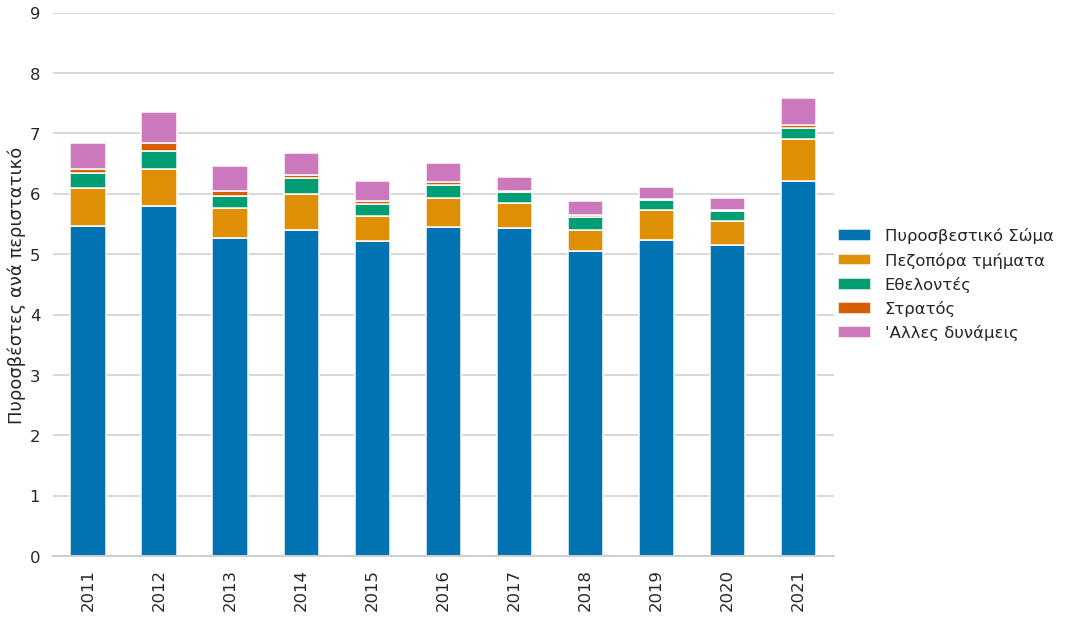

In [227]:
#| code-summary: Ραβδόγραμμα
#| fig-cap: "Μέσος όρος πυροσβεστών ανά περιστατικό ετησίος (2011-2021)"
#| column: page
#| fig-align: left

fig, ax = plt.subplots(figsize=(14, 10))
personnel.plot.bar(stacked=True, ax=ax)
sns.despine(ax=ax, top=True, left=True, right=True)

ax.xaxis.grid(False)
ax.set_ylim([0, 9])

handles, _ = ax.get_legend_handles_labels()
labels = ['Πυροσβεστικό Σώμα', 'Πεζοπόρα τμήματα', 'Εθελοντές', 'Στρατός', "'Αλλες δυνάμεις"]
ax.legend(handles, labels, loc='right', bbox_to_anchor=(1.3,0.5), frameon=False)
ax.set(xlabel='', ylabel='Πυροσβέστες ανά περιστατικό');

Ο μέσος όρος των πυροσβεστών που επιχειρούν ανά περιστατικό ετησίως είναι σχετικά σταθερός. Ακόμη και το 2012 και 2021 που επιχείρησαν κατά μέσο όρο περισσότεροι πυροσβέστες οι καταστροφές ήταν εκτεταμένες όπως είδαμε από τα προηγούμενα γραφήματα.

In [234]:
vehicles = wildfires_subset.groupby(wildfires_subset.start.dt.year).mean()[
                                                                       ['fire_trucks',
                                                                        'local_authorities',
                                                                        'private_trucks',
                                                                        'other_trucks',
                                                                        'helicopters',
                                                                        'canadair_new',
                                                                        'canadair_old',
                                                                        'pzl',
                                                                        'gru']
                                                                            ]

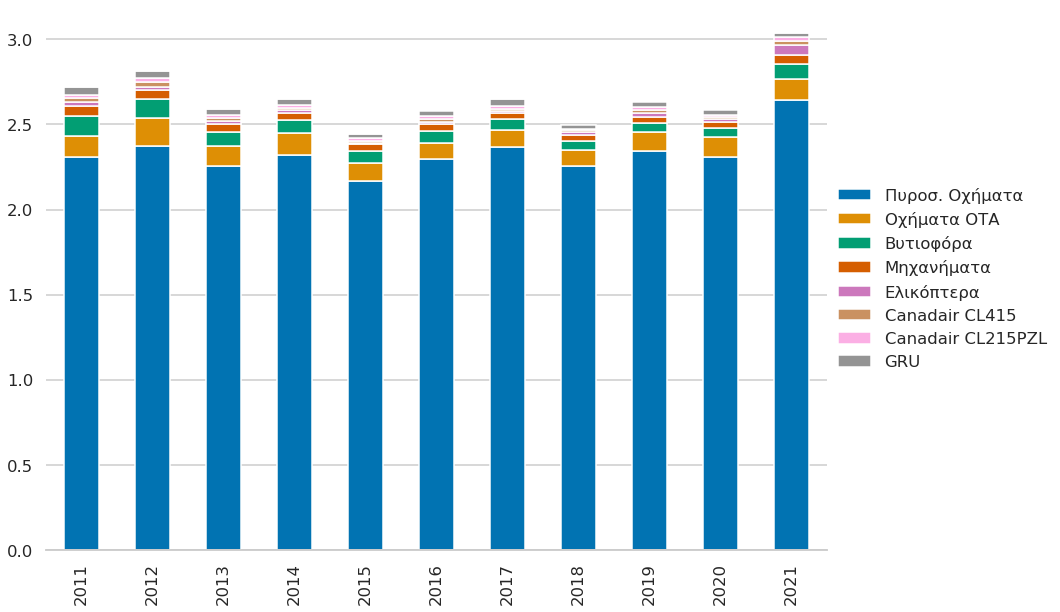

In [239]:
#| code-summary: Ραβδόγραμμα
#| fig-cap: "Μέσος όρος οχημάτων ανά περιστατικό ετησίος (2011-2021)"
#| column: page
#| fig-align: left

fig, ax = plt.subplots(figsize=(14, 10))
vehicles.plot.bar(stacked=True, ax=ax)

ax.xaxis.grid(False)
sns.despine(ax=ax, top=True, left=True, right=True)

handles, _ = ax.get_legend_handles_labels()
labels = ['Πυροσ. Οχήματα', 'Οχήματα ΟΤΑ', 'Βυτιοφόρα', 'Μηχανήματα', 'Ελικόπτερα', 'Canadair CL415', 'Canadair CL215' 'PZL', 'GRU']
ax.legend(handles, labels, loc='right', bbox_to_anchor=(1.3,0.5), frameon=False)
ax.set_xlabel('');

Ακριβώς ίδια είναι η εικόνα από το μέσο όρο οχημάτων που χρησιμοποιήθηκαν στην πυρόσβεση ανά έτος.

### Συμπεράσματα

Δυστυχώς παρόλες τις προσπάθειες πυρόσβεσης δεν εμφανίζεται κάποια βελτίωση στην ετήσια αποτίμηση των ζημιών από πυρκαγιές. Αν συνυπολογίσουμε ότι οι καιρικές συνθήκες όπως ο καύσωνας και η ξηρασία επιδεινώνουν την κατάσταση και λόγω της κλιματικής αλλαγής τέτοιες συνθήκες θα είναι συχνότερες, πρέπει να αναμένουμε ότι τα επόμενα χρόνια η συχνότητα, η διάρκεια και η έκταση των ζημιών θα αυξάνονται. Ανάλογα λοιπόν, θα πρέπει να αυξήσουμε την προσπάθεια πυρόσβεσης ποιοτικά και ποσοτικά, όπως επίσης και τις προσπάθεις πρόληψης, αν θέλουμε μελλοντικά να διατηρήσουμε ή ακόμη και να μειώσουμε το ετήσιο κόστος ζημιών από πυρκαγιές.